<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-11 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Generative Adversarial Networks </21> </html>

### Demonstration how to generate images of handwritten digits (like MNIST dataset) using
### a Deep Convolutional Generative Adversarial Network (DCGAN)

[source](https://arxiv.org/pdf/1511.06434.pdf)

![sample output](https://tensorflow.org/images/gan/dcgan.gif)

##### (GANs) can be described as models which are trained simultaneously by an adversarial process.
A *generator* learns to create images that look real, while a *discriminator* learns to tell real images apart from fakes.
During training, the *generator* progressively becomes better at creating images that look real, while the *discriminator becomes better at telling them apart. The process reaches equilibrium when the *discriminator* can no longer distinguish real images from fakes.

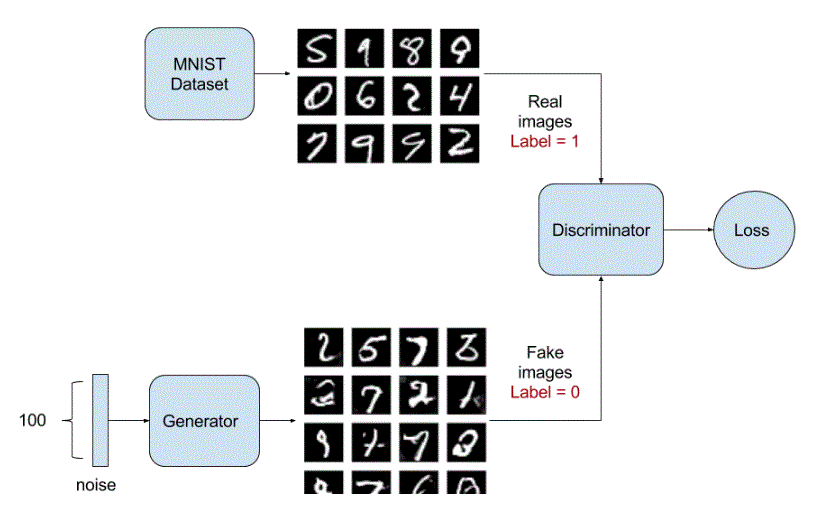

##### This notebook uses on the MNIST dataset. The following animation shows a series of images produced by the *generator* as it was trained for 50 epochs. The images begin as random noise, and increasingly resemble hand written digits over time.

### Import

image.png

In [1]:
import tensorflow as tf

2026-04-20 08:04:14.283191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776672254.871545      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776672254.993225      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776672256.397684      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776672256.397728      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776672256.397731      55 computation_placer.cc:177] computation placer alr

In [2]:
#

image.png

In [3]:
tf.__version__

'2.19.0'

In [4]:
#

______________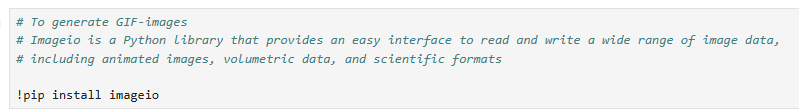

In [5]:
!pip install imageio

In [6]:
#

______________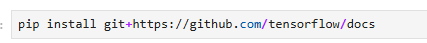

In [7]:
pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-1kukg7cm
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-1kukg7cm
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.1.14.40212-py3-none-any.whl size=186922 sha256=c78f509198ffa1edd865d2394e0f32f0071d20351167af305721ff5f32a329ad
  Stored in directory: /tmp/pip-ephem-wheel-cache-3qppn1lf/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs
Note: you may need to restart the kernel to use updated packages.


In [8]:
#

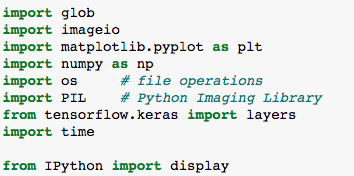


In [9]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os 
import PIL
from tensorflow.keras import layers
import time

from IPython import display

In [10]:
#

### MNIST Dataset
After treining the generator will generate handwritten digits resembling the MNIST data.


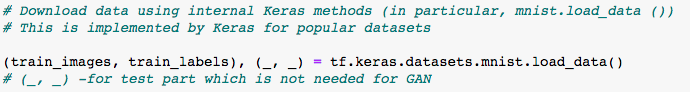

In [11]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
#

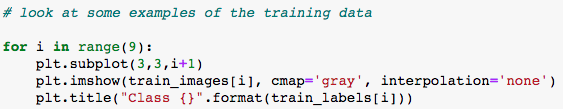

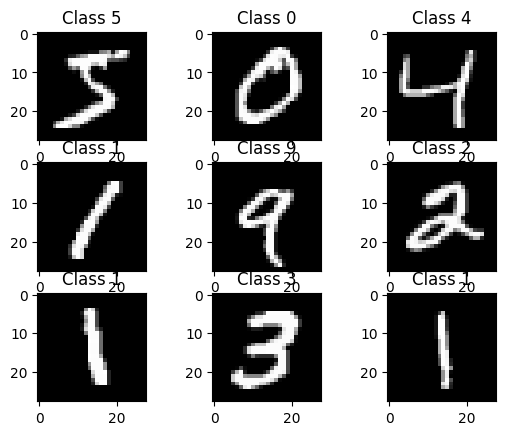

In [13]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray', interpolation='none')
    plt.title("Class {}".format(train_labels[i]))

In [14]:
#

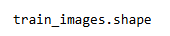

In [15]:
train_images.shape

(60000, 28, 28)

In [16]:
#

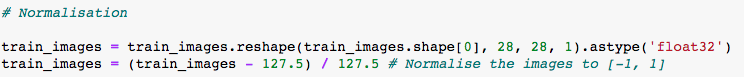

In [17]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

In [18]:
#

_______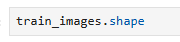

In [19]:
train_images.shape

(60000, 28, 28, 1)

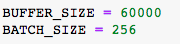

In [20]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [21]:
#

In [22]:
#tf.data.Dataset.from_tensor_slices?

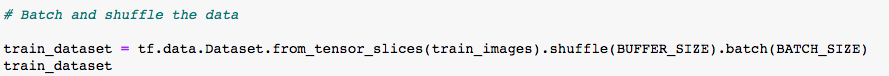

In [23]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
train_dataset

I0000 00:00:1776672311.910484      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776672311.916611      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<_BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>

In [24]:
#

### The Generator

The generator uses `tf.keras.layers.Conv2DTranspose` (upsampling) layers to produce an image from a seed (random noise). Start with a `Dense` layer that takes this seed as input, then upsample several times until you reach the desired image size of 28x28x1. Notice the `tf.keras.layers.LeakyReLU` activation for each layer, except the output layer which uses tanh.

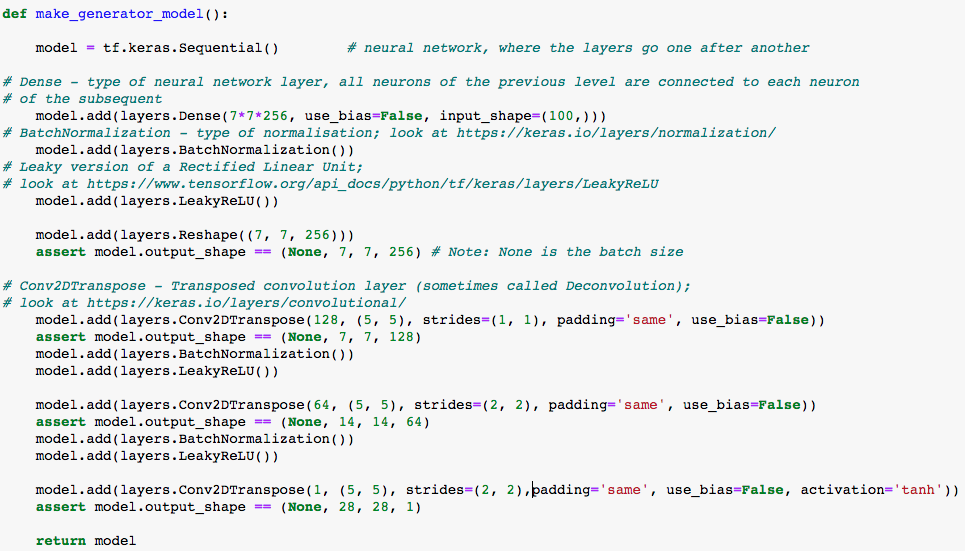


In [25]:
def make_generator_model():

    model = tf.keras.Sequential()  # neural network, where the layers go one after another

    # Dense - type of neural network layer, all neurons of the previous level are connected to each neuron
    # of the subsequent
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)))

    # BatchNormalization - type of normalisation
    model.add(layers.BatchNormalization())

    # Leaky version of a Rectified Linear Unit
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    # Conv2DTranspose - Transposed convolution layer (sometimes called Deconvolution)
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2),
                                    padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

In [26]:
#

Use the generator to create an image.


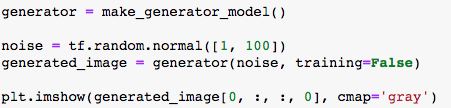



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776672314.557414      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


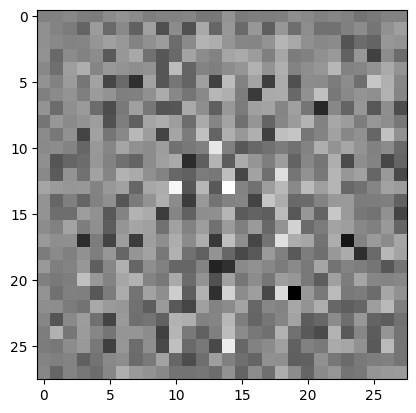

In [27]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [28]:
#

image.png



In [29]:
generator?

Signature:   generator(*args, **kwargs)
Type:        Sequential
String form: <Sequential name=sequential, built=True>
File:        /usr/local/lib/python3.12/dist-packages/keras/src/models/sequential.py
Docstring:  
`Sequential` groups a linear stack of layers into a `Model`.

Examples:

```python
model = keras.Sequential()
model.add(keras.Input(shape=(16,)))
model.add(keras.layers.Dense(8))

# Note that you can also omit the initial `Input`.
# In that case the model doesn't have any weights until the first call
# to a training/evaluation method (since it isn't yet built):
model = keras.Sequential()
model.add(keras.layers.Dense(8))
model.add(keras.layers.Dense(4))
# model.weights not created yet

# Whereas if you specify an `Input`, the model gets built
# continuously as you are adding layers:
model = keras.Sequential()
model.add(keras.Input(shape=(16,)))
model.add(keras.layers.Dense(8))
len(model.weights)  # Returns "2"

# When using the delayed-build pattern (no input shape specified)

In [30]:
# Describe why the image does not have a structure?

In [31]:
#

### The Discriminator

The discriminator is a CNN-based image classifier.

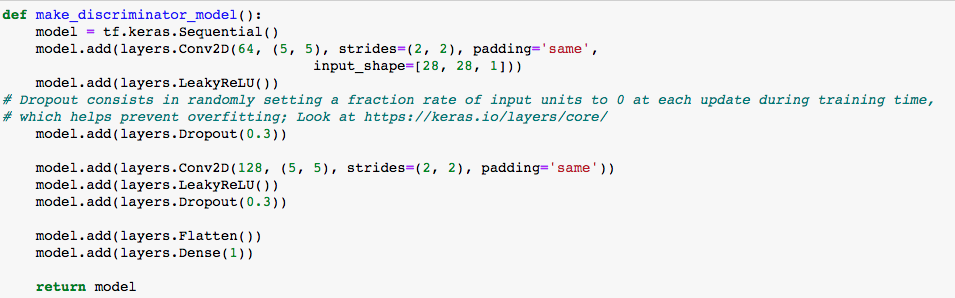

In [32]:
def make_discriminator_model():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())

    # Dropout consists in randomly setting a fraction rate of input units to 0
    # which helps prevent overfitting
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [33]:
#

Use the (as yet untrained) discriminator to classify the generated images as real or fake. The model will be trained to output positive values for real images, and negative values for fake images.

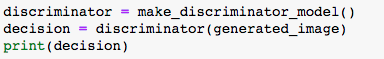

In [34]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)

print(decision)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-0.00178564]], shape=(1, 1), dtype=float32)


image.png

## Define the loss and optimizers

Define loss functions and optimizers for both models.


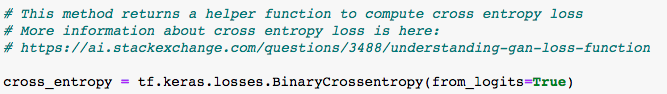

In [35]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [36]:
#

### Discriminator loss

This method quantifies how well the discriminator is able to distinguish real images from fakes. It compares the discriminator's predictions on real images to an array of 1s, and the discriminator's predictions on fake (generated) images to an array of 0s.

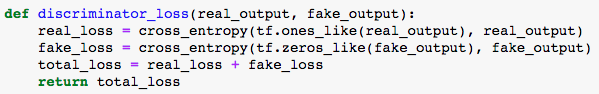

In [37]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [38]:
#

### Generator loss
The generator's loss quantifies how well it was able to trick the discriminator. Intuitively, if the generator is performing well, the discriminator will classify the fake images as real (or 1). Here, we will compare the discriminators decisions on the generated images to an array of 1s.

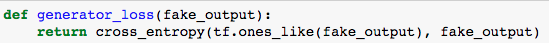

In [39]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [40]:
#

The discriminator and the generator optimizers are different since we will train two networks separately.

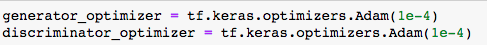

In [41]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [42]:
#

image.png

In [43]:
tf.keras.optimizers.Adam?

Init signature:
tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='adam',
    **kwargs,
)
Docstring:     
Optimizer that implements the Adam algorithm.

Adam optimization is a stochastic gradient descent method that is based on
adaptive estimation of first-order and second-order moments.

According to
[Kingma et al., 2014](http://arxiv.org/abs/1412.6980),
the method is "*computationally
efficient, has little memory requirement, invariant to diagonal rescaling of
gradients, and is well suited for problems that are large in terms of
data/parameters*".

Args:
    learning_rate: A float, a
        `keras.optimizers.schedules.LearningRateSchedule` instance, or
        a callable that 

### Save checkpoints
It is useful in case a long running training task is interrupted.


image.png

In [44]:
tf.train.Checkpoint?

Init signature: tf.train.Checkpoint(root=None, **kwargs)
Docstring:     
Manages saving/restoring trackable values to disk.

TensorFlow objects may contain trackable state, such as `tf.Variable`s,
`tf.keras.optimizers.Optimizer` implementations, `tf.data.Dataset` iterators,
`tf.keras.Layer` implementations, or  `tf.keras.Model` implementations.
These are called **trackable objects**.

A `Checkpoint` object can be constructed to save either a single or group of
trackable objects to a checkpoint file. It maintains a `save_counter` for
numbering checkpoints.

Example:

```python
model = tf.keras.Model(...)
checkpoint = tf.train.Checkpoint(model)

# Save a checkpoint to /tmp/training_checkpoints-{save_counter}. Every time
# checkpoint.save is called, the save counter is increased.
save_path = checkpoint.save('/tmp/training_checkpoints')

# Restore the checkpointed values to the `model` object.
checkpoint.restore(save_path)
```

Example 2:

```python
import tensorflow as tf
import os

check

In [45]:
#

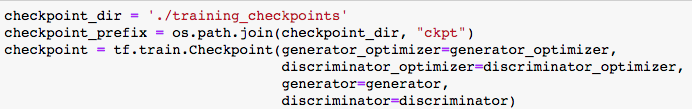

In [46]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [47]:
#

## Training loop



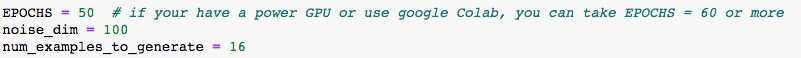


In [48]:
EPOCHS = 60
noise_dim = 100
num_examples_to_generate = 16

In [49]:
#

image.png

In [50]:
tf.random.normal?

Signature:
tf.random.normal(
    shape,
    mean=0.0,
    stddev=1.0,
    dtype=tf.float32,
    seed=None,
    name=None,
)
Docstring:
Outputs random values from a normal distribution.

Example that generates a new set of random values every time:

>>> tf.random.set_seed(5);
>>> tf.random.normal([4], 0, 1, tf.float32)
<tf.Tensor: shape=(4,), dtype=float32, numpy=..., dtype=float32)>

Example that outputs a reproducible result:

>>> tf.random.set_seed(5);
>>> tf.random.normal([2,2], 0, 1, tf.float32, seed=1)
<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[-1.3768897 , -0.01258316],
      [-0.169515   ,  1.0824056 ]], dtype=float32)>

In this case, we are setting both the global and operation-level seed to
ensure this result is reproducible.  See `tf.random.set_seed` for more
information.

Args:
  shape: A 1-D integer Tensor or Python array. The shape of the output tensor.
  mean: A Tensor or Python value of type `dtype`, broadcastable with `stddev`.
    The mean of the normal di

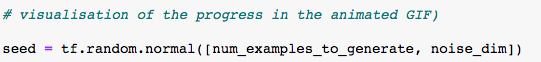

In [51]:
# visualisation of the progress in the animated GIF)

seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [52]:
#

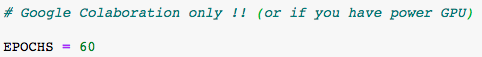

In [53]:
#

The training loop begins with generator receiving a random seed as input. That seed is used to produce an image. The discriminator is then used to classify real images (drawn from the training set) and fakes images (produced by the generator). The loss is calculated for each of these models, and the gradients are used to update the generator and discriminator.

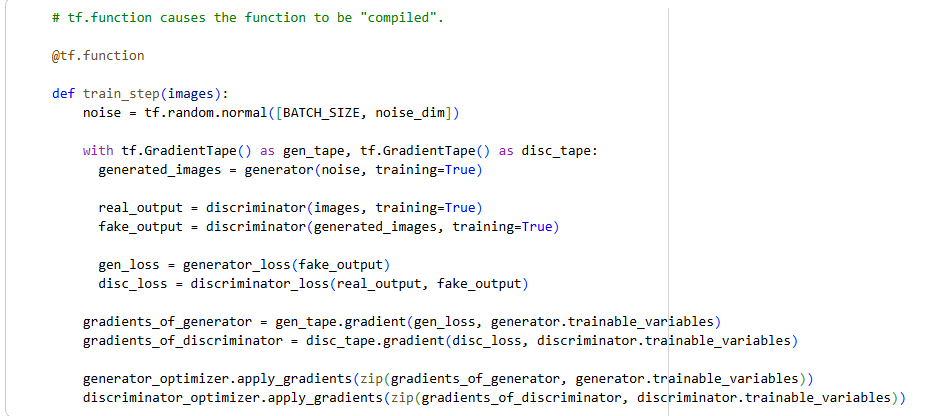

In [54]:
# tf.function causes the function to be "compiled".

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [55]:
#

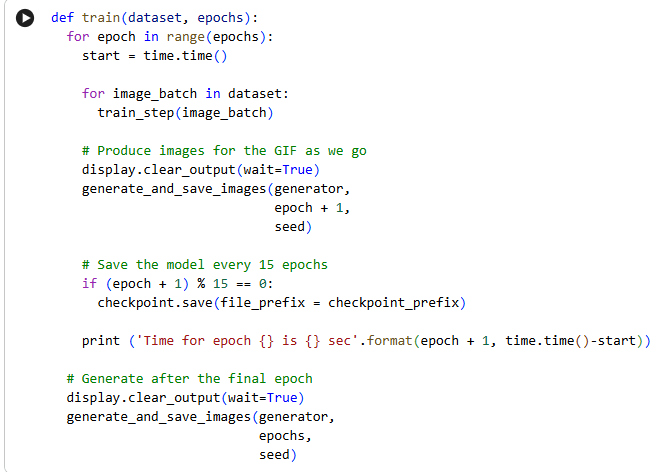

In [56]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        # Produce images for the GIF as we go
        display.clear_output(wait=True)
        generate_and_save_images(generator,
                                 epoch + 1,
                                 seed)

        # Save the model every 15 epochs
        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print('Time for epoch {} is {} sec'.format(epoch + 1, time.time() - start))

    # Generate after the final epoch
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epochs,
                             seed)

In [57]:
#

**Generate and save images**



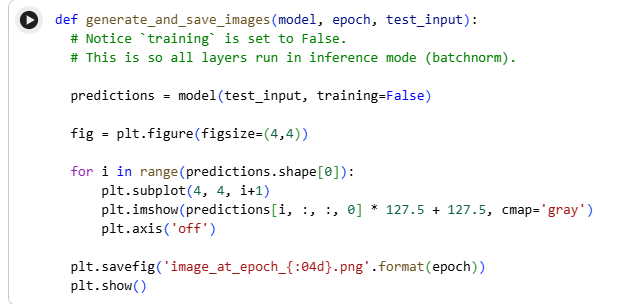

In [58]:
def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False.
    # This is so all layers run in inference mode (batchnorm).

    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

In [59]:
#

## Train the model
train() - training the generator and discriminator simultaneously.
It's important that the generator and discriminator do not overpower each other (e.g., that they train at a similar rate).

At the beginning of the training, the generated images look like random noise. As training progresses, the generated digits will look increasingly real. After about 50 epochs, they resemble MNIST digits.

In [60]:
# Save your Jupyter Notebook before start the next cell

### Before starting the next cell, read the Lab Logbook requirements.
### To take a screenshot of the required epoch, use Shift+Window+S for Windows
### and Shift+Command+5 for Mac.

image.png

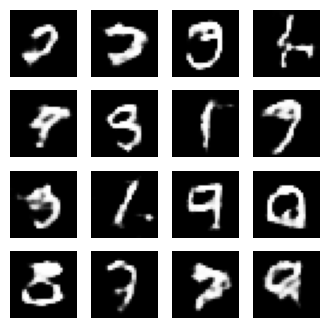

In [61]:
train(train_dataset, EPOCHS)

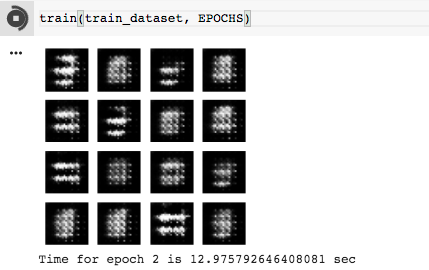

image.png

In [62]:
checkpoint.restore?

Signature: checkpoint.restore(save_path, options=None)
Docstring:
Restores a training checkpoint.

Restores this `Checkpoint` and any objects it depends on.

This method is intended to be used to load checkpoints created by `save()`.
For checkpoints created by `write()` use the `read()` method which does not
expect the `save_counter` variable added by `save()`.

`restore()` either assigns values immediately if variables to restore have
been created already, or defers restoration until the variables are
created. Dependencies added after this call will be matched if they have a
corresponding object in the checkpoint (the restore request will queue in
any trackable object waiting for the expected dependency to be added).

```python
checkpoint = tf.train.Checkpoint( ... )
checkpoint.restore(path)

# You can additionally pass options to restore():
options = tf.CheckpointOptions(experimental_io_device="/job:localhost")
checkpoint.restore(path, options=options)
```

To ensure that loading is 

Restore the latest checkpoint.

image.png

In [63]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [64]:
#

### Show the result as a GIF-file


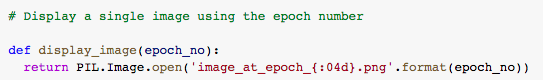

In [65]:
# Display a single image using the epoch number

def display_image(epoch_no):
    return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

In [66]:
#

image.png

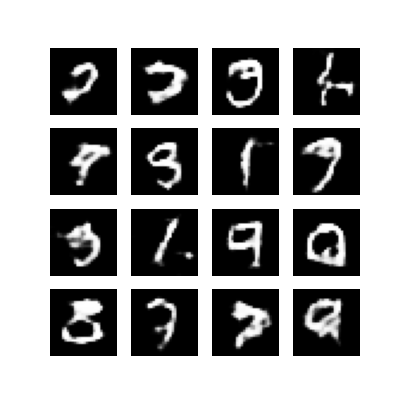

In [67]:
display_image(EPOCHS)

In [68]:
# describe the results

Use `imageio` to create an animated gif using the images saved during training.

_________________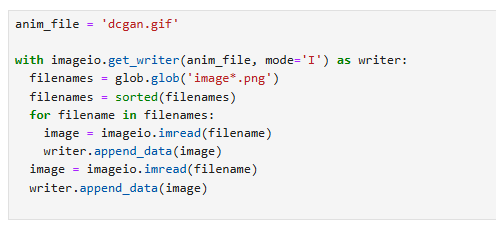

In [69]:
anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('image*.png')
    filenames = sorted(filenames)

    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

    image = imageio.imread(filename)
    writer.append_data(image)

/tmp/ipykernel_55/1464927392.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
/tmp/ipykernel_55/1464927392.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


In [70]:
#

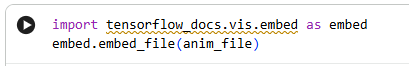


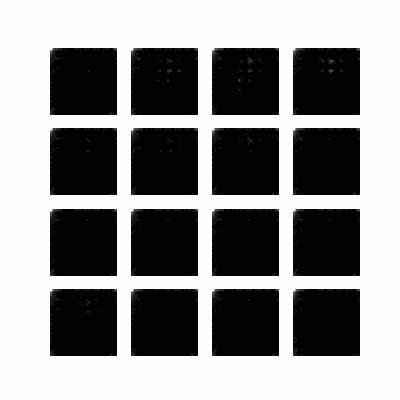

In [71]:
import tensorflow_docs.vis.embed as embed

embed.embed_file(anim_file)

If you're working in Colab you can download the animation with the code below:

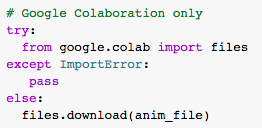

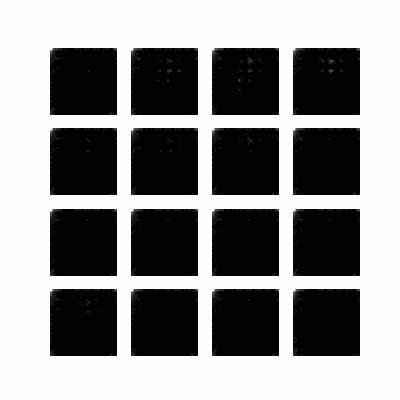

In [72]:
from IPython.display import Image

Image(filename=anim_file)

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### You must copy a screenshot of the GAN training result at a specific epoch to your logbook. The screenshot must contain the digital images, the epoch number and the time spent training for this epoch.

### Determine this epoch number using the following method:

#### Take the last two digits from your SID.
#### If this number is less than or equal to 50, it is the required epoch number.
#### If it exceeds 50, divide it by 50 and round up if necessary.
#### For example, if your SID is 2187467, and the last two digits are 67, which is greater than 50.
#### Divide by 2, resulting in 33.5. Round up to 34, and this becomes your epoch number.

<html> <h4 style="font-style:bold; color:red;"> NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB. </h4> </html>

In [73]:
TARGET_EPOCH = 39

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        print('Time for epoch {} is {} sec'.format(epoch + 1, time.time() - start))

        if epoch + 1 == TARGET_EPOCH:
            break

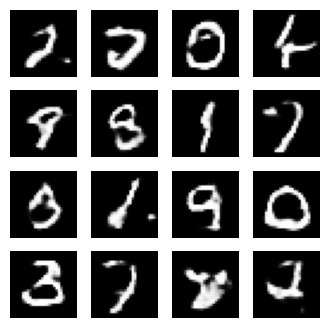

Time for epoch 39 is 12.778510093688965 sec


In [74]:
train(train_dataset, EPOCHS)

## Task 2: Using the code above, generate the image of the faces using sample real data.

In [75]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from IPython import display

In [76]:
BATCH_SIZE = 256
IMG_SIZE = 64

data_dir = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba" 

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 202599 files.


In [77]:
def preprocess(image):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image

train_dataset = train_dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

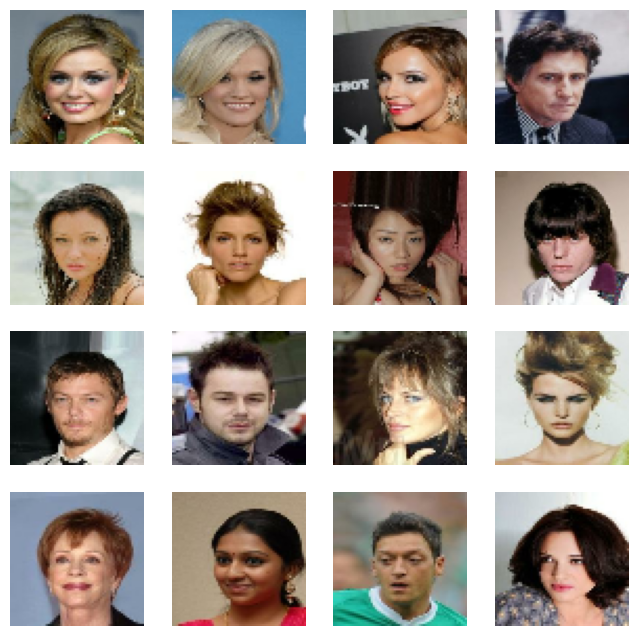

In [78]:
for image_batch in train_dataset.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow((image_batch[i] + 1) / 2)
        plt.axis("off")
    plt.show()

In [79]:
def make_generator_model():
    model = tf.keras.Sequential()

    model.add(layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256)

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 8, 8, 128)

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 16, 16, 128)

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 32, 32, 64)

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same',
                                     use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 64, 64, 3)

    return model

In [80]:
def make_discriminator_model():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=[64, 64, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [81]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator = make_generator_model()
discriminator = make_discriminator_model()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [82]:
EPOCHS = 30
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [83]:
@tf.function
def train_step(images):
    noise = tf.random.normal([tf.shape(images)[0], noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [84]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = (predictions[i] + 1) / 2
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [85]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        print('Time for epoch {} is {:.2f} sec'.format(epoch + 1, time.time() - start))

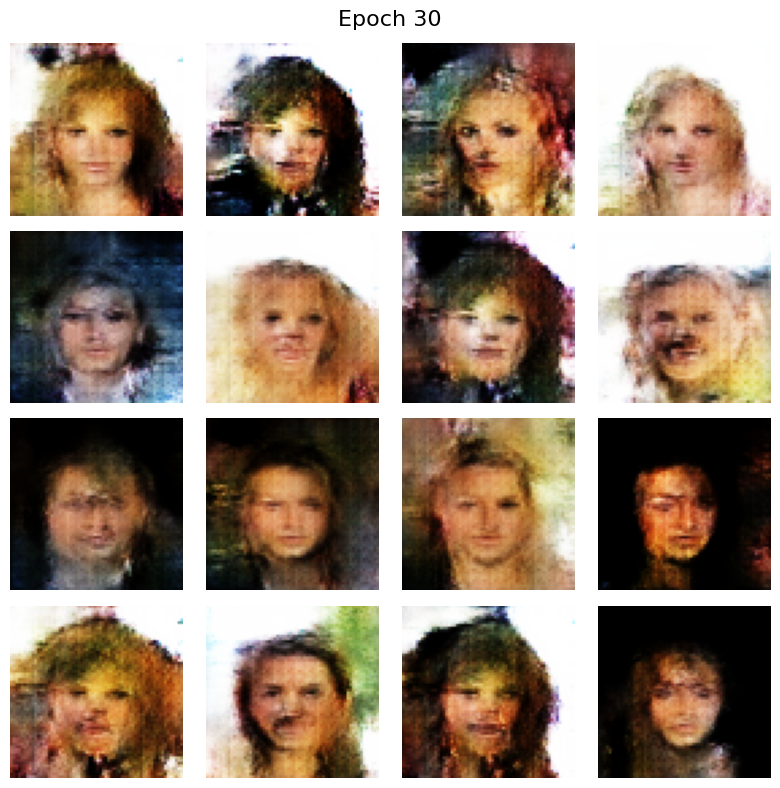

Time for epoch 30 is 217.78 sec


In [86]:
train(train_dataset, EPOCHS)

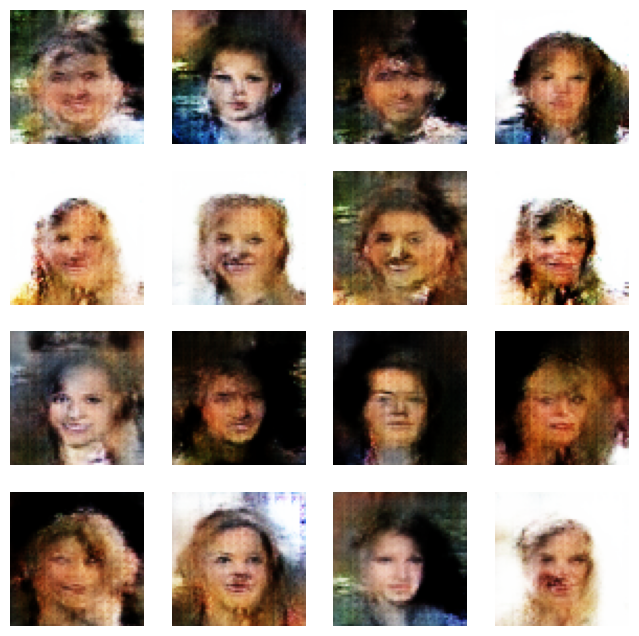

In [87]:
noise = tf.random.normal([16, 100])
generated_faces = generator(noise, training=False)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow((generated_faces[i] + 1) / 2)
    plt.axis("off")
plt.show()